# 🏆 Part 2: Perceptron Competition

Welcome to the **IN4310 Neural Network Championship**!

Today, we move from theory to practice. Your goal is to design the best possible **Multi-Layer Perceptron (MLP)** to classify handwritten digits (MNIST).

### The Rules:
1.  We use a strict **Train / Validation / Test** split.
2.  We all use the same Training Loop.
3.  **You** design the architecture (Number of layers, size of layers, activation functions).
4.  At the end, we run a **Stress Test** on the Test Set to see whose model is truly robust.

---

## 1. Setup & Data Loading
First, let's import the necessary tools and load the MNIST dataset.
We will split the training data into **Training** (to teach the model) and **Validation** (to check progress).

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
import time
from datetime import datetime
from tqdm.notebook import tqdm  # Progress bar library

# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# --- DATA LOADING ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 1. Load Full Datasets
try:
    full_train_set = torchvision.datasets.MNIST(root='./Datasets', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root='./Datasets', train=False, download=True, transform=transform)
except:
    print("⚠️ Failed to download datasets. Please check your internet connection or dataset path.")

# 2. Split Train into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size
train_set, val_set = torch.utils.data.random_split(full_train_set, [train_size, val_size])

# 3. Create DataLoaders
BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Ready:")
print(f"   - Training:   {len(train_set)} images")
print(f"   - Validation: {len(val_set)} images")
print(f"   - Test:       {len(test_set)} images")

✅ Device: cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.49MB/s]


✅ Data Ready:
   - Training:   48000 images
   - Validation: 12000 images
   - Test:       10000 images


## 2. Model Architecture Theory

Before you build your model, let's look at an example of a **3-Layer MLP**.

### The Anatomy of a Linear Layer
`nn.Linear(in_features, out_features)`
* **in_features**: The size of the input vector.
* **out_features**: The number of neurons in this layer.

### Constraints
1.  **Input Layer:** Must always be `28 * 28 = 784` (because MNIST images are 28x28 pixels).
2.  **Output Layer:** Must always be `10` (because we have digits 0-9).
3.  **Hidden Layers:** You can have as many as you want, with any size you want!

---

In [9]:
# Example Baseline Model
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),             # 1. Unroll 28x28 image into a vector of 784
            
            nn.Linear(784, 2),      # 2. Hidden Layer 1 (128 neurons)
            nn.ReLU(),                #    Activation Function
            
            nn.Linear(2, 2),       # 3. Hidden Layer 2 (64 neurons)
            nn.ReLU(),                #    Activation Function
            
            nn.Linear(2, 10)         # 4. Output Layer (10 classes)
        )

    def forward(self, x):
        return self.layers(x)

### Activation Functions: The "Spark" of the Brain

Linear layers (`Wx + b`) are just matrix multiplications. Without activation functions, stacking 100 linear layers is mathematically equivalent to just 1 layer. 

We need **non-linearity**. Here are your choices:

1.  **`nn.ReLU()` (Rectified Linear Unit):** 
    * *Logic:* `If x < 0, return 0. Else return x.`
    * *Pros:* Fast, solves vanishing gradient problem. **The industry standard.**
    * *Cons:* Can have "dead neurons" (if inputs are always negative).

2.  **`nn.Sigmoid()`:** 
    * *Logic:* Squashes numbers between 0 and 1.
    * *Pros:* Good for probabilities.
    * *Cons:* **Vanishing Gradient** (learning stops in deep networks). Old school.

3.  **`nn.Tanh()`:**
    * *Logic:* Squashes numbers between -1 and 1.
    * *Pros:* Zero-centered, often better than Sigmoid.

4.  **`nn.LeakyReLU(0.01)`:**
    * *Logic:* Like ReLU, but negative numbers are multiplied by 0.01 instead of becoming 0.
    * *Pros:* Fixes the "dead neuron" problem.

5.  **`nn.Dropout(p=0.5)`:** (Not an activation, but a Regularizer)
    * *Logic:* Randomly zeroes out 50% of neurons during training.
    * *Why?* Prevents **Overfitting** (memorization).

## 3. Build Your Fighter!

This is where you come in. Create your own class. Experiment with shapes and activations.

**Ideas to try:**
* **Deep & Narrow:** Many layers (5+), but small size (e.g., 32 neurons).
* **Shallow & Wide:** 1 hidden layer with 1000 neurons.
* **The Funnel:** 784 -> 512 -> 256 -> 128 -> 10.
* **The Dropout:** Add `nn.Dropout(0.2)` after activations.

In [ ]:
# --- DEFINE YOUR MODEL HERE ---
class MyCompetitorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            
            # --- EDIT THIS SECTION ---
            nn.Linear(784, 3),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(3, 3),
            nn.ReLU(),
            # -------------------------
            
            nn.Linear(3, 10) # Output layer (Do not change size 10)
        )

    def forward(self, x):
        return self.layers(x)

## 4. The Training Engine

We will now define a robust training function. It will:
1.  Create a unique folder `models/ModelName_DateTime`.
2.  Train the model using the **Train Set**.
3.  Evaluate using the **Validation Set** after every epoch.
4.  Save logs to `log.csv` **immediately** after each epoch.
5.  Save the model weights (`current.pth` and `best.pth`).

In [5]:
def train_competitor(model_class, epochs=5, lr=0.001):
    # 1. Setup Directories
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_name = model_class.__name__
    save_dir = f"models/{model_name}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n🥊 STARTING TRAINING: {model_name}")
    print(f"📂 Saving results to: {save_dir}")
    
    # 2. Initialize Model & Tools
    # Note: 'device' is assumed to be defined globally
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 3. Initialize CSV Log File (for training history)
    log_path = f"{save_dir}/log.csv"
    with open(log_path, "w") as f:
        f.write("epoch,train_loss,val_loss,val_acc\n")
    
    best_acc = 0.0
    
    # --- TRAINING LOOP ---
    for epoch in range(epochs):
        # A. Train Phase
        model.train()
        train_loss = 0.0
        
        # Progress Bar
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        
        avg_train_loss = train_loss / len(train_loader)
        
        # B. Validation Phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                v_loss = criterion(output, labels)
                val_loss += v_loss.item()
                
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        # Update progress bar description
        pbar.set_postfix(train_loss=f"{avg_train_loss:.4f}", val_acc=f"{val_acc:.2f}%")
        
        # C. Save Training Logs
        with open(log_path, "a") as f:
            f.write(f"{epoch+1},{avg_train_loss:.4f},{avg_val_loss:.4f},{val_acc:.2f}\n")
        
        # D. Save Checkpoints
        # 1. Always save the current state (Last Model)
        torch.save(model.state_dict(), f"{save_dir}/current_model.pth")
        
        # 2. Save only if it is the best model so far
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{save_dir}/best_model.pth")
            
    print(f"🏆 Training Done! Best Validation Accuracy: {best_acc:.2f}%")

    # --- TEST SET EVALUATION ---
    print("\n🔍 Evaluating both models on Test Set...")
    
    # Helper function to evaluate a specific checkpoint
    def evaluate_checkpoint(weights_path):
        # Re-initialize a clean model
        eval_model = model_class().to(device)
        # Load weights
        eval_model.load_state_dict(torch.load(weights_path))
        eval_model.eval()
        
        correct = 0
        total = 0
        loss_sum = 0.0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                output = eval_model(images)
                loss = criterion(output, labels)
                loss_sum += loss.item()
                
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_loss = loss_sum / len(test_loader)
        acc = 100 * correct / total
        return acc, avg_loss

    # 1. Evaluate Current (Last) Model
    curr_acc, curr_loss = evaluate_checkpoint(f"{save_dir}/current_model.pth")
    print(f"   -> Current Model Test Acc: {curr_acc:.2f}%")

    # 2. Evaluate Best Model
    best_ver_acc, best_ver_loss = evaluate_checkpoint(f"{save_dir}/best_model.pth")
    print(f"   -> Best Model Test Acc:    {best_ver_acc:.2f}%")

    # --- SAVE TEST RESULTS TO CSV ---
    test_csv_path = f"{save_dir}/test_results.csv"
    with open(test_csv_path, "w") as f:
        f.write("model_version,test_acc,test_loss\n")
        f.write(f"current_model,{curr_acc:.4f},{curr_loss:.4f}\n")
        f.write(f"best_model,{best_ver_acc:.4f},{best_ver_loss:.4f}\n")
    
    print(f"💾 Test results saved to: {test_csv_path}")

    # --- PLOTTING ---
    try:
        df = pd.read_csv(log_path)
        plt.figure(figsize=(12, 5))
        
        # Subplot 1: Loss
        plt.subplot(1, 2, 1)
        plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
        plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'{model_name} - Loss')
        
        # Subplot 2: Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(df['epoch'], df['val_acc'], label='Val Acc', color='green')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.title(f'{model_name} - Accuracy')
        
        # Save plot BEFORE showing it
        plt.savefig(f"{save_dir}/training_plot.png")
        plt.show()
        
    except Exception as e:
        print(f"⚠️ Could not plot results: {e}")

### Run the Training!
Run this cell to train your model.

In [6]:
# Train Baseline
train_competitor(BaselineModel, epochs=5, lr=0.001)

# Train Your Custom Model
train_competitor(MyCompetitorModel, epochs=5, lr=0.001)


🥊 STARTING TRAINING: BaselineModel
📂 Saving results to: models/BaselineModel_2026-02-05_11-28-54


Epoch 1/5:   0%|          | 0/750 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/750 [00:00<?, ?batch/s]

KeyboardInterrupt: 

## 5. The Leaderboard 🏅

Now let's see how all the models compare! This script looks into the `models/` folder and compiles the results.

Found 2 models...


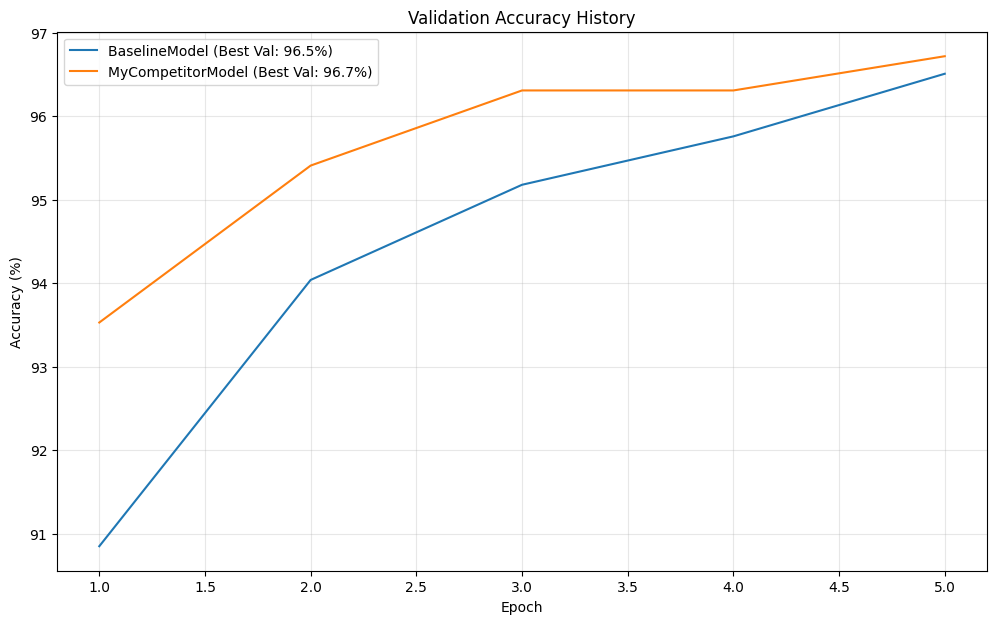


🏅 LEADERBOARD (Sorted by Test Accuracy):


,Model,Test Acc,Best Val Acc
1,MyCompetitorModel,96.89,96.72
2,BaselineModel,96.66,96.51


In [9]:
def show_leaderboard():
    # Find all log.csv files in the models directory
    log_files = glob.glob("models/*/log.csv")
    results = []
    
    plt.figure(figsize=(12, 7))
    
    print(f"Found {len(log_files)} models...")
    
    for log_file in log_files:
        folder_name = os.path.dirname(log_file)
        # Extract model name (remove timestamp for cleaner legend)
        model_name_full = os.path.basename(folder_name)
        model_name_short = model_name_full.split('_20')[0] 
        
        # 1. Read Training History (Validation Acc)
        try:
            df_log = pd.read_csv(log_file)
            best_val_acc = df_log['val_acc'].max()
            
            # Plot the validation curve
            plt.plot(df_log['epoch'], df_log['val_acc'], 
                     label=f"{model_name_short} (Best Val: {best_val_acc:.1f}%)")
        except Exception as e:
            print(f"⚠️ Error reading log for {model_name_short}: {e}")
            best_val_acc = 0.0

        # 2. Read Test Results (Test Acc)
        test_file = os.path.join(folder_name, "test_results.csv")
        test_acc = 0.0 # Default if file not found
        
        if os.path.exists(test_file):
            try:
                df_test = pd.read_csv(test_file)
                # We want the test accuracy of the 'best_model' version
                row = df_test[df_test['model_version'] == 'best_model']
                if not row.empty:
                    test_acc = row['test_acc'].values[0]
            except Exception as e:
                print(f"⚠️ Error reading test results for {model_name_short}: {e}")
        
        # 3. Append to results list
        results.append({
            "Model": model_name_short,
            "Best Val Acc": best_val_acc,
            "Test Acc": test_acc,
            "Folder": folder_name
        })

    # Finalize Plot
    plt.title("Validation Accuracy History")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Create DataFrame and Sort by TEST Accuracy
    leaderboard_df = pd.DataFrame(results)
    
    # Sort descending by Test Acc, then by Val Acc as a tie-breaker
    leaderboard_df = leaderboard_df.sort_values(by=["Test Acc", "Best Val Acc"], ascending=[False, False])
    
    print("\n🏅 LEADERBOARD (Sorted by Test Accuracy):")
    # Reset index to look like a ranking (1, 2, 3...)
    display_df = leaderboard_df[['Model', 'Test Acc', 'Best Val Acc']].reset_index(drop=True)
    display_df.index += 1 
    
    # Check if we are in Jupyter to use display(), otherwise print
    try:
        display(display_df)
    except NameError:
        print(display_df)
        
    return leaderboard_df

# Run the function
leaderboard = show_leaderboard()

## 6. The "Real World" Stress Test 💥

We will now test the best models on the **TEST set** (which they have never seen).
Moreover, we will transform the test images to see if the models are robust to placement.

### Visualization of the Test
Here is an example of what we feed the model:

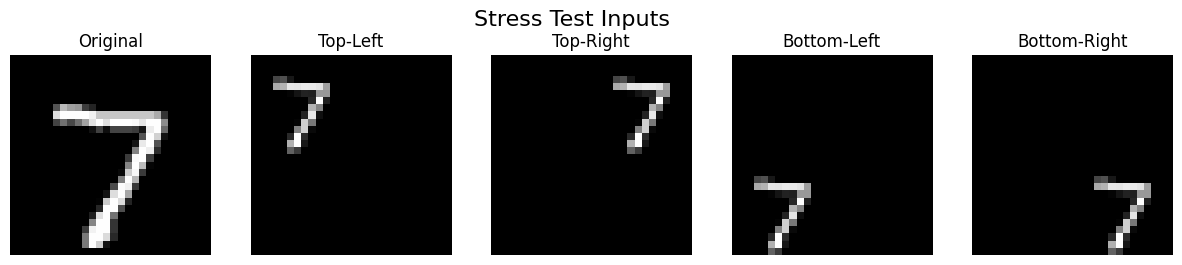

In [10]:
def show_stress_example():
    images, _ = next(iter(test_loader))
    img = images[0]
    _, H, W = img.shape
    small_h, small_w = H // 2, W // 2
    small_img = F.interpolate(img.unsqueeze(0), size=(small_h, small_w), mode='bilinear', align_corners=False)[0]

    variants = [img] # Original
    
    # Create corners
    corners = [(0, small_h, 0, small_w), (0, small_h, small_w, W), 
               (small_h, H, 0, small_w), (small_h, H, small_w, W)]
    
    for y1, y2, x1, x2 in corners:
        canvas = torch.full_like(img, -1.0)
        canvas[:, y1:y2, x1:x2] = small_img
        variants.append(canvas)

    titles = ["Original", "Top-Left", "Top-Right", "Bottom-Left", "Bottom-Right"]
    
    plt.figure(figsize=(15, 3))
    for i, v in enumerate(variants):
        plt.subplot(1, 5, i+1)
        plt.imshow(v[0], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.suptitle("Stress Test Inputs", fontsize=16)
    plt.show()

show_stress_example()

In [11]:
def run_stress_test(leaderboard_df):
    print("\n🧪 RUNNING STRESS TEST (Corner Robustness)...")
    
    # 1. Prepare Stress Batch (1000 images)
    loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)
    images, labels = next(iter(loader))
    
    B, C, H, W = images.shape
    small_h, small_w = H // 2, W // 2
    small_imgs = F.interpolate(images, size=(small_h, small_w), mode='bilinear', align_corners=False)
    
    # Create variants
    variants = {"Original": images}
    corners = {
        "Top-Left":     (0, small_h, 0, small_w),
        "Top-Right":    (0, small_h, small_w, W),
        "Bottom-Left":  (small_h, H, 0, small_w),
        "Bottom-Right": (small_h, H, small_w, W),
    }
    
    for name, (y1, y2, x1, x2) in corners.items():
        canvas = torch.full_like(images, -1.0)
        canvas[:, :, y1:y2, x1:x2] = small_imgs
        variants[name] = canvas

    # 2. Test Models using Reflection
    stress_results = []
    
    for index, row in leaderboard_df.iterrows():
        model_name = row['Model']  # e.g., "BaselineModel"
        model_path = os.path.join(row['Folder'], "best_model.pth")
        
        # Try to find the class in the global scope by its name
        ModelClass = globals().get(model_name)
        
        if ModelClass is not None:
            # Found the class via reflection!
            try:
                model = ModelClass().to(device)
            except Exception as e:
                print(f"⚠️ Found class '{model_name}' but failed to init: {e}")
                continue
        else:
            print(f"❌ Skipping '{model_name}': Class not found and no default provided.")
            continue
            
        # Load Weights
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
        except RuntimeError as e:
            print(f"⚠️ Skipping {model_name}: Architecture mismatch. {e}")
            continue
            
        model.eval()
        
        # 3. Run Inference
        res = {"Model": model_name}
        avg_score = 0
        
        with torch.no_grad():
            for v_name, v_imgs in variants.items():
                v_imgs = v_imgs.to(device)
                outputs = model(v_imgs)
                _, preds = torch.max(outputs, 1)
                
                acc = (preds.cpu() == labels).float().mean().item() * 100
                res[v_name] = round(acc, 1)
                avg_score += acc
        
        res["AVG"] = round(avg_score / 5, 1)
        stress_results.append(res)
        
    # 4. Display
    if not stress_results:
        print("❌ No models were successfully tested.")
        return None

    df_stress = pd.DataFrame(stress_results).sort_values(by="AVG", ascending=False)
    
    print("\n💥 STRESS TEST RESULTS:")
    cols = ['Model', 'AVG'] + [k for k in variants.keys()]
    display(df_stress[cols])
    
    return df_stress


stress_df = run_stress_test(leaderboard)


🧪 RUNNING STRESS TEST (Corner Robustness)...

💥 STRESS TEST RESULTS:


,Model,AVG,Original,Top-Left,Top-Right,Bottom-Left,Bottom-Right
0,MyCompetitorModel,28.3,96.6,9.5,13.6,10.4,11.4
1,BaselineModel,25.6,96.9,6.3,8.0,7.9,8.7
